# (1) Invariant curvature analysis: MassiveLion vs. Lion

device = ```cuda:0```

## Interpretation: MassiveLion vs `lion_bad` vs `lion_ok`

The invariant/function-space probes now separate the three runs cleanly.

The key new fact is that `lion_bad` had **negative curvature coupling** because $\beta_1 > \beta_2$. That makes its pathology much less mysterious: the optimizer dynamics were effectively amplifying the wrong curvature response rather than damping it. The diagnostics show exactly that kind of unstable, stiff solution.

### Normal-Mode Spectrum

The Fisher/KL normal-mode spectrum is the most mechanistic summary. It treats the local predictive KL as an elastic energy,

$$
KL(p_\theta || p_{\theta+\delta}) \;\approx\; \frac{1}{2}\delta^\top F\delta,
$$

so eigenvalues of the filter-normalized Fisher/KL matrix behave like **spring constants**.

`lion_bad` has a dramatically larger `lambda_max` and `random_rayleigh_mean` than both `m_lion` and `lion_ok`. This means it is not just sharp in one unlucky direction; its functional stiffness scale is globally much higher. Its `stiff_mode_ratio` is also large, indicating strong anisotropy: rare directions are extremely stiff relative to typical directions.

By contrast, `lion_ok` has normal-mode stiffness comparable to or lower than `m_lion`, though its typical random stiffness is slightly higher. This supports the idea that Lion itself is not necessarily pathological; the bad behavior came from the negative-coupling regime.

### Thermal Susceptibility

The thermal probes measure typical response to random filter-normalized perturbations. This is a finite-temperature / basin-volume view: instead of asking for the worst direction, we ask how much nearby normalized volume changes the function.

Both `mean_KL` and `p95_KL` show:

$$
\texttt{lion_bad} \;\gg\; \texttt{lion_ok} \;\gtrsim\; \texttt{m_lion}.
$$

So `lion_bad` is thermally more susceptible across all perturbation scales. Random perturbations already change its predictive distribution much more than they change the others. `lion_ok` and `m_lion` remain close, with `m_lion` usually slightly more stable.

### Adversarial KL

The adversarial KL probe is the zero-temperature, worst-case version of functional sensitivity. It asks: how much can an adversary change the model’s predictions under a scale-aware perturbation?

Here the separation is extreme. `lion_bad` has much larger KL even at tiny perturbation scales, then catastrophically explodes at moderate scales. This is the clearest signature of unstable stiff modes. `lion_ok` and `m_lion` track each other closely at small scales, only rising at larger perturbations.

This means the previous “Lion is functionally brittle” conclusion should be refined:

> The pathological Lion run was functionally brittle because it was in the negative curvature-coupling regime, not because all Lion-like fits must be brittle.

### Adversarial CE Sharpness

The CE sharpness plot tells the same story in supervised-loss space. `lion_bad` becomes explosively sharp, with loss increases spanning many orders of magnitude. `lion_ok` and `m_lion` remain well behaved and close together until larger perturbation scales.

At the largest scales, both `m_lion` and `lion_ok` eventually become vulnerable, but this is less informative because large perturbations leave the local regime. The small-to-moderate perturbation range is the important one, and there `lion_bad` is the clear outlier.

### Conclusion

The converging interpretation is:

**`lion_bad` is not merely a high-norm or unlucky Lion solution. It is dynamically pathological because \(\beta_1 > \beta_2\) gives negative curvature coupling, producing extremely stiff and unstable functional modes.**

The invariant probes all agree:

- `lion_bad` has enormous worst-case functional sensitivity.
- `lion_bad` has much higher typical thermal susceptibility.
- `lion_bad` has a vastly larger Fisher/KL stiffness scale.
- `lion_ok` is mechanically much healthier and often close to `m_lion`.
- `m_lion` remains the most consistently stable or near-stable model across typical perturbation probes.

Mechanistically, MassiveLion behaves like a curvature-damped system that reaches a stable functional basin. `lion_ok` is a reasonable Lion solution without the negative-coupling instability. `lion_bad` behaves like an anti-damped or wrong-sign curvature-coupled system: it lands in a basin with hidden stiff modes that explode under normalized adversarial perturbations.


In [9]:
# display_probe_interpretation();

### `adv_ce`: Filter-normalized adversarial CE sharpness

**Question.** How much can an adversary increase supervised loss using a scale-aware perturbation of the weights?

**Mechanics view.** Worst-case elastic energy under a normalized displacement. The filter normalization changes coordinates from raw weights to relative per-filter strain, so large parameter norms do not automatically look flatter or sharper.

**Thermo view.** This is a zero-temperature / adversarial probe: it finds the most damaging local direction instead of averaging over typical thermal kicks.

**Large values mean.** A nearby scale-aware displacement can strongly increase CE loss. The basin has a brittle direction in label-loss space.

**Small values mean.** The supervised loss is locally stable to worst-case normalized weight perturbations at this perturb_scale.

**Primary readouts.** `sharpness, relative_sharpness, sharp_acc`

**Caveat.** CE can explode when logits become confidently wrong. Interpret small perturb_scale values before accuracy collapses most heavily.

### `adv_kl`: Filter-normalized adversarial function-space KL

**Question.** How much can an adversary change the predictive distribution using a scale-aware weight perturbation?

**Mechanics view.** For small perturbations, KL(p_theta || p_theta+delta) is roughly 0.5 * delta^T F delta, so this is a direct stiffness measurement of the learned function in normalized coordinates.

**Thermo view.** This is still a zero-temperature probe, but the energy is information-geometric rather than label CE.

**Large values mean.** The input-output map has a stiff functional direction. The model can change predictions substantially without a large normalized parameter displacement.

**Small values mean.** The function is locally stable; predictions are insensitive to worst-case normalized perturbations at this scale.

**Primary readouts.** `kl, pert_acc, pert_loss`

**Caveat.** When KL is near numerical floor, ratios can look dramatic but the qualitative ordering matters more than exact factors.

### `thermal`: Filter-normalized thermal susceptibility

**Question.** How much does the function fluctuate under random isotropic normalized weight noise?

**Mechanics view.** Measures typical susceptibility rather than the stiffest mode. Think of random small kicks to a mechanical system and observe the average response.

**Thermo view.** Finite-temperature basin-volume probe. Mean and tail KL estimate how much nearby normalized volume preserves the function.

**Large values mean.** A substantial fraction of nearby normalized parameter volume changes the function or loss.

**Small values mean.** Typical nearby perturbations are harmless. If adversarial probes are large but thermal probes are small, the brittleness is anisotropic and concentrated in rare directions.

**Primary readouts.** `mean_kl, p95_kl, mean_loss_increase, worst_acc`

**Caveat.** Random directions in very high dimension often miss narrow stiff subspaces, so use this alongside adversarial probes.

### `normal_modes`: Filter-normalized Fisher/KL normal modes

**Question.** What are the stiffest functional modes, and how anisotropic is the local geometry?

**Mechanics view.** Treat S F S as a stiffness matrix, where F is the predictive Fisher/KL Hessian and S maps normalized coordinates to real weights. Eigenvectors are normal modes; eigenvalues are spring constants.

**Thermo view.** The top eigenvalue gives the stiffest low-temperature mode, while random Rayleigh probes estimate typical thermal stiffness.

**Large values mean.** Large lambda_max means a very stiff functional direction. A large stiff_mode_ratio means a highly anisotropic basin with rare sharp modes and many softer directions.

**Small values mean.** The local function-space stiffness scale is lower, or less anisotropic if stiff_mode_ratio is also small.

**Primary readouts.** `lambda_max, top_eigs, random_rayleigh_mean, stiff_mode_ratio`

**Caveat.** Lanczos estimates depend on max_batches, random initialization, and number of steps. Compare runs under identical settings.

In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
## HIDE CODE


from gra.experiments.vision.models import WideResNet, ResNet18, ConvNet, MLP


def _ckpt_arg(ckpt, key, default=None):
    args = ckpt.get("args", {})
    return args.get(key, default) if isinstance(args, dict) else getattr(args, key, default)

def _clean_state_dict(sd):
    return {
        k.removeprefix("_orig_mod."): v
        for k, v in sd.items()
    }

def ckpt_to_vision_model(ckpt, device="cpu"):
    dataset = str(_ckpt_arg(ckpt, "dataset", "CIFAR10"))
    model_name = _ckpt_arg(ckpt, "model", "resnet")
    num_classes = 1000 if "imagenet" in dataset.lower() else 10

    model_cls = {
        "resnet": ResNet18,
        "wrn": WideResNet,
        "convnet": ConvNet,
        "mlp": MLP,
    }[model_name]

    model = model_cls(num_classes=num_classes).to(device)
    model.load_state_dict(_clean_state_dict(ckpt["model"]), strict=True)
    model.eval()
    return model

In [3]:
from gra.diagnostics.invariant_curvature_metrics import (
    DEFAULT_PERTURB_SCALES,
    display_probe_interpretation,
    filter_normalized_adversarial_sharpness,
    filter_normalized_adversarial_kl,
    filter_normalized_thermal_susceptibility,
    filter_normalized_fisher_normal_modes,
    plot_scale_sweep,
    plot_normal_mode_bars,
    compare_to_reference,
)

import pandas as pd
from gra.utils.dataset import make_dataloader

In [4]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## step 0 — load stuff

### load runs

In [5]:
%%time


from gra.experiments.common.checkpointing import resolve_resume_source, load_checkpoint

run_paths = {
    "adamw": "pal-lab/GRA-CIFAR10/tcan6k5g",
    "m_lion": "pal-lab/GRA-CIFAR10/ikft1odq",
    "lion_ok": "pal-lab/GRA-CIFAR10/h9vl6ugr",
    "lion_bad": "pal-lab/GRA-CIFAR10/5ljlbsbj",
    "m_signum": "pal-lab/GRA-CIFAR10/umh5vvwk",
}

sources = {k: resolve_resume_source(v) for k, v in run_paths.items()}
ckpts = {
    k: load_checkpoint(src.checkpoint_path, map_location="cpu")
    for k, src in sources.items()
}

models = {k: ckpt_to_vision_model(ch) for k, ch in ckpts.items()}

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hadi/.netrc.


CPU times: user 1.81 s, sys: 379 ms, total: 2.19 s
Wall time: 6.05 s


### Load data

In [6]:
train_loader, val_loader = make_dataloader(
    dataset="CIFAR10",
    batch_size=256,
    device=device,
)

loader = val_loader

## step 1 — run the big loop

In [7]:
%%time


shared = {
    "device": device,
    "max_batches": 20,
    "perturb_scales": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1],
}

adv_ce_rows = []
adv_kl_rows = []
thermal_rows = []
normal_mode_rows = []

for label, model in tqdm(models.items()):
    for perturb_scale in shared["perturb_scales"]:
        out = filter_normalized_adversarial_sharpness(
            model,
            loader,
            device=shared["device"],
            perturb_scale=perturb_scale,
            ascent_steps=10,
            max_batches=shared["max_batches"],
        )
        adv_ce_rows.append({"label": label, **out})

        out = filter_normalized_adversarial_kl(
            model,
            loader,
            device=shared["device"],
            perturb_scale=perturb_scale,
            ascent_steps=10,
            max_batches=shared["max_batches"],
        )
        adv_kl_rows.append({"label": label, **out})

        out = filter_normalized_thermal_susceptibility(
            model,
            loader,
            device=shared["device"],
            perturb_scale=perturb_scale,
            samples=30,
            max_batches=shared["max_batches"],
        )
        thermal_rows.append({"label": label, **out})

    out = filter_normalized_fisher_normal_modes(
        model,
        loader,
        device=shared["device"],
        max_batches=10,
        lanczos_steps=12,
        random_probes=8,
    )
    normal_mode_rows.append({"label": label, **out})

adv_ce_df = pd.DataFrame(adv_ce_rows)
adv_kl_df = pd.DataFrame(adv_kl_rows)
thermal_df = pd.DataFrame(thermal_rows)
normal_modes_df = pd.DataFrame(normal_mode_rows)


  0%|          | 0/5 [00:00<?, ?it/s]

CPU times: user 9min 31s, sys: 5min 29s, total: 15min
Wall time: 13min 43s


## step 2 — inspect / visualize

### plots

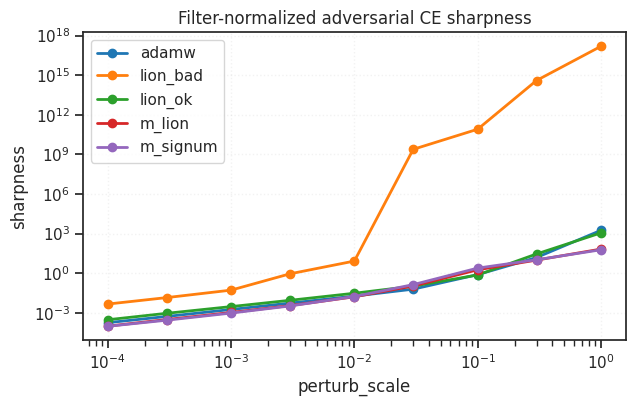

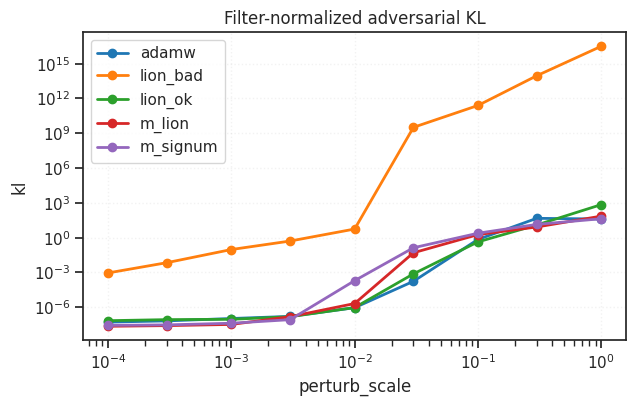

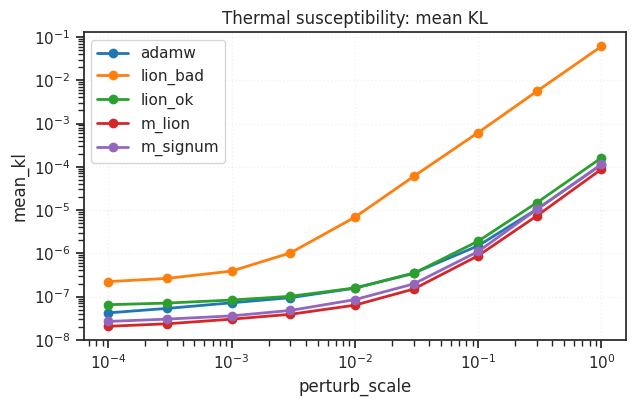

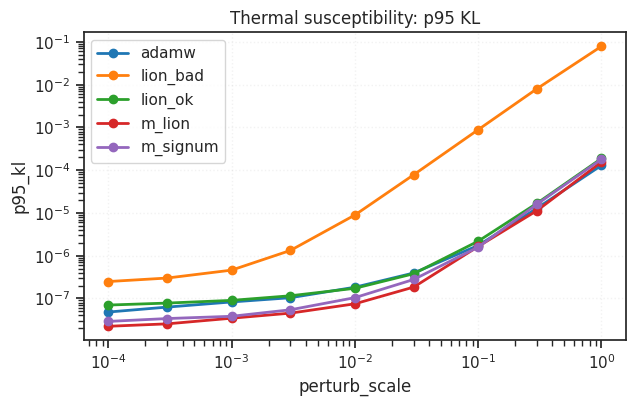

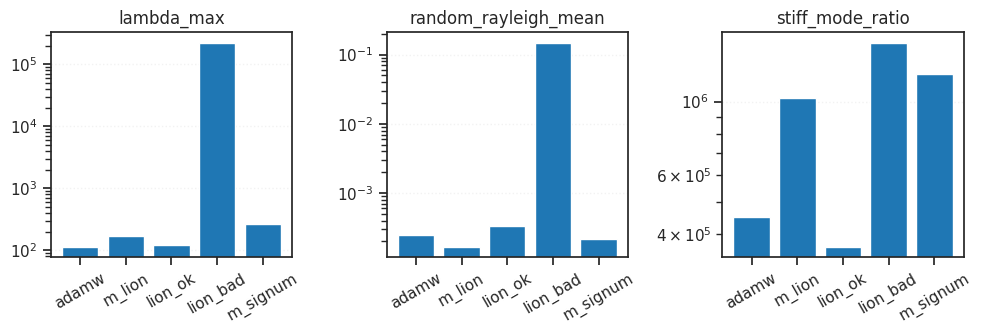

In [8]:
plot_scale_sweep(adv_ce_df, "sharpness", title="Filter-normalized adversarial CE sharpness")
plot_scale_sweep(adv_kl_df, "kl", title="Filter-normalized adversarial KL")
plot_scale_sweep(thermal_df, "mean_kl", title="Thermal susceptibility: mean KL")
plot_scale_sweep(thermal_df, "p95_kl", title="Thermal susceptibility: p95 KL")

plot_normal_mode_bars(normal_modes_df);

### relative to m_lion

In [9]:
# Useful ratio tables against MassiveLion.
adv_ce_vs_mlion = compare_to_reference(adv_ce_df, "sharpness", reference_label="m_lion")
adv_kl_vs_mlion = compare_to_reference(adv_kl_df, "kl", reference_label="m_lion")
thermal_vs_mlion = compare_to_reference(thermal_df, "mean_kl", reference_label="m_lion")

display(adv_ce_vs_mlion)
display(adv_kl_vs_mlion)
display(thermal_vs_mlion)


label,perturb_scale,adamw,lion_bad,lion_ok,m_lion,m_signum,adamw_over_m_lion,adamw_minus_m_lion,lion_bad_over_m_lion,lion_bad_minus_m_lion,lion_ok_over_m_lion,lion_ok_minus_m_lion,m_lion_over_m_lion,m_lion_minus_m_lion,m_signum_over_m_lion,m_signum_minus_m_lion
0,0.0001,0.000176,4.546112e-03,0.000294,0.000096,0.000094,1.841193,0.000080,4.752760e+01,4.450460e-03,3.074294,0.000198,1.0,0.0,0.982046,-0.000002
1,0.0003,0.000520,1.399356e-02,0.000903,0.000304,0.000271,1.711423,0.000216,4.609007e+01,1.368995e-02,2.972866,0.000599,1.0,0.0,0.893743,-0.000032
2,0.0010,0.001762,5.155075e-02,0.002915,0.001044,0.000943,1.687286,0.000718,4.937516e+01,5.050669e-02,2.792168,0.001871,1.0,0.0,0.903212,-0.000101
3,0.0030,0.005325,8.870783e-01,0.008715,0.003455,0.003252,1.541313,0.001870,2.567747e+02,8.836236e-01,2.522617,0.005260,1.0,0.0,0.941275,-0.000203
4,0.0100,0.018215,8.229956e+00,0.029991,0.016080,0.016934,1.132807,0.002136,5.118187e+02,8.213876e+00,1.865106,0.013911,1.0,0.0,1.053115,0.000854
5,0.0300,0.061029,2.403107e+09,0.103021,0.106189,0.134735,0.574718,-0.045160,2.263042e+10,2.403107e+09,0.970167,-0.003168,1.0,0.0,1.268822,0.028546
6,0.1000,0.772530,8.027951e+10,0.725524,1.793478,2.407045,0.430744,-1.020948,4.476190e+10,8.027951e+10,0.404534,-1.067955,1.0,0.0,1.342110,0.613567
7,0.3000,15.191350,3.941699e+14,28.263963,9.707215,10.285832,1.564955,5.484135,4.060587e+13,3.941699e+14,2.911645,18.556748,1.0,0.0,1.059607,0.578618
8,1.0000,1755.821259,1.544401e+17,1124.333954,66.348792,58.822911,26.463500,1689.472467,2.327701e+15,1.544401e+17,16.945809,1057.985162,1.0,0.0,0.886571,-7.525880


label,perturb_scale,adamw,lion_bad,lion_ok,m_lion,m_signum,adamw_over_m_lion,adamw_minus_m_lion,lion_bad_over_m_lion,lion_bad_minus_m_lion,lion_ok_over_m_lion,lion_ok_minus_m_lion,m_lion_over_m_lion,m_lion_minus_m_lion,m_signum_over_m_lion,m_signum_minus_m_lion
0,0.0001,5.172320e-08,9.000959e-04,6.872920e-08,2.264386e-08,2.692305e-08,2.284204,2.907934e-08,3.975010e+04,9.000733e-04,3.035224,4.608533e-08,1.0,0.0,1.188978,4.279182e-09
1,0.0003,6.614619e-08,6.907446e-03,8.481446e-08,2.586776e-08,2.994188e-08,2.557090,4.027843e-08,2.670292e+05,6.907420e-03,3.278772,5.894671e-08,1.0,0.0,1.157498,4.074121e-09
2,0.0010,1.060503e-07,9.380548e-02,9.080281e-08,3.272992e-08,4.148977e-08,3.240165,7.332042e-08,2.866047e+06,9.380545e-02,2.774306,5.807289e-08,1.0,0.0,1.267641,8.759853e-09
3,0.0030,1.617462e-07,5.068066e-01,1.516202e-07,1.523644e-07,8.431213e-08,1.061575,9.381763e-09,3.326279e+06,5.068064e-01,0.995116,-7.441855e-10,1.0,0.0,0.553358,-6.805228e-08
4,0.0100,9.055109e-07,5.485270e+00,9.291199e-07,2.075474e-06,1.945804e-04,0.436291,-1.169963e-06,2.642899e+06,5.485268e+00,0.447666,-1.146354e-06,1.0,0.0,93.752274,1.925050e-04
5,0.0300,1.713797e-04,3.216989e+09,7.484621e-04,4.939638e-02,1.333180e-01,0.003469,-4.922500e-02,6.512600e+10,3.216989e+09,0.015152,-4.864792e-02,1.0,0.0,2.698942,8.392160e-02
6,0.1000,6.929758e-01,2.460751e+11,4.262021e-01,1.812200e+00,2.379761e+00,0.382395,-1.119224e+00,1.357881e+11,2.460751e+11,0.235185,-1.385998e+00,1.0,0.0,1.313189,5.675616e-01
7,0.3000,4.599975e+01,9.008319e+13,1.225934e+01,8.238544e+00,1.377581e+01,5.583480,3.776120e+01,1.093436e+13,9.008319e+13,1.488046,4.020792e+00,1.0,0.0,1.672117,5.537266e+00
8,1.0000,4.018710e+01,3.123029e+16,6.968011e+02,7.107198e+01,4.234771e+01,0.565442,-3.088487e+01,4.394177e+14,3.123029e+16,9.804160,6.257291e+02,1.0,0.0,0.595842,-2.872427e+01


label,perturb_scale,adamw,lion_bad,lion_ok,m_lion,m_signum,adamw_over_m_lion,adamw_minus_m_lion,lion_bad_over_m_lion,lion_bad_minus_m_lion,lion_ok_over_m_lion,lion_ok_minus_m_lion,m_lion_over_m_lion,m_lion_minus_m_lion,m_signum_over_m_lion,m_signum_minus_m_lion
0,0.0001,4.191967e-08,2.213287e-07,6.472214e-08,2.051926e-08,2.654162e-08,2.042942,2.140041e-08,10.786388,2.008095e-07,3.154213,4.420287e-08,1.0,0.0,1.293498,6.022359e-09
1,0.0003,5.312945e-08,2.627388e-07,7.058505e-08,2.341949e-08,3.005750e-08,2.268600,2.970996e-08,11.218810,2.393193e-07,3.013945,4.716556e-08,1.0,0.0,1.283440,6.638013e-09
2,0.0010,7.162583e-08,3.875603e-07,8.287261e-08,3.001163e-08,3.567225e-08,2.386602,4.161419e-08,12.913669,3.575487e-07,2.761349,5.286098e-08,1.0,0.0,1.188614,5.660620e-09
3,0.0030,9.418854e-08,1.020898e-06,1.012928e-07,3.882890e-08,4.775286e-08,2.425733,5.535965e-08,26.292223,9.820691e-07,2.608695,6.246387e-08,1.0,0.0,1.229828,8.923966e-09
4,0.0100,1.562880e-07,6.824071e-06,1.576943e-07,6.315071e-08,8.477863e-08,2.474842,9.313732e-08,108.060089,6.760920e-06,2.497111,9.454359e-08,1.0,0.0,1.342481,2.162793e-08
5,0.0300,3.484402e-07,5.998309e-05,3.421170e-07,1.490757e-07,1.959457e-07,2.337338,1.993645e-07,402.366776,5.983402e-05,2.294922,1.930414e-07,1.0,0.0,1.314404,4.687000e-08
6,0.1000,1.493251e-06,6.181580e-04,1.911391e-06,8.782868e-07,1.101879e-06,1.700186,6.149638e-07,703.822506,6.172797e-04,2.176272,1.033104e-06,1.0,0.0,1.254578,2.235926e-07
7,0.3000,1.048008e-05,5.599122e-03,1.487179e-05,7.386106e-06,1.037903e-05,1.418891,3.093976e-06,758.061354,5.591735e-03,2.013482,7.485685e-06,1.0,0.0,1.405210,2.992922e-06
8,1.0000,1.119767e-04,6.096368e-02,1.613533e-04,8.807871e-05,1.138325e-04,1.271326,2.389801e-05,692.150026,6.087560e-02,1.831922,7.327460e-05,1.0,0.0,1.292396,2.575383e-05


### results df

In [10]:
display(adv_ce_df)
display(adv_kl_df)
display(thermal_df)
display(normal_modes_df)

,label,perturb_scale,base_loss,base_acc,sharp_loss,sharp_acc,sharpness,relative_sharpness,ascent_steps,max_batches
0,adamw,0.0001,0.562457,0.910937,5.626332e-01,0.910937,1.761138e-04,3.131152e-04,10,20
1,adamw,0.0003,0.562457,0.910937,5.629767e-01,0.910937,5.196109e-04,9.238233e-04,10,20
2,adamw,0.0010,0.562457,0.910937,5.642187e-01,0.910742,1.761632e-03,3.132029e-03,10,20
3,adamw,0.0030,0.562457,0.910937,5.677819e-01,0.910547,5.324766e-03,9.466973e-03,10,20
4,adamw,0.0100,0.562457,0.910937,5.806724e-01,0.909570,1.821535e-02,3.238531e-02,10,20
5,adamw,0.0300,0.562457,0.910937,6.234859e-01,0.905273,6.102880e-02,1.085039e-01,10,20
6,adamw,0.1000,0.562457,0.910937,1.334987e+00,0.833984,7.725303e-01,1.373492e+00,10,20
7,adamw,0.3000,0.562457,0.910937,1.575381e+01,0.150195,1.519135e+01,2.700890e+01,10,20
8,adamw,1.0000,0.562457,0.910937,1.756384e+03,0.102539,1.755821e+03,3.121698e+03,10,20
9,m_lion,0.0001,0.255891,0.934961,2.559868e-01,0.935156,9.565204e-05,3.737998e-04,10,20


,label,perturb_scale,base_loss,base_acc,pert_loss,pert_acc,kl,ascent_steps,max_batches
0,adamw,0.0001,0.562457,0.910937,5.624541e-01,0.910742,5.172320e-08,10,20
1,adamw,0.0003,0.562457,0.910937,5.624528e-01,0.910937,6.614619e-08,10,20
2,adamw,0.0010,0.562457,0.910937,5.624662e-01,0.910742,1.060503e-07,10,20
3,adamw,0.0030,0.562457,0.910937,5.624597e-01,0.910742,1.617462e-07,10,20
4,adamw,0.0100,0.562457,0.910937,5.624263e-01,0.910742,9.055109e-07,10,20
5,adamw,0.0300,0.562457,0.910937,5.621469e-01,0.910547,1.713797e-04,10,20
6,adamw,0.1000,0.562457,0.910937,1.161937e+00,0.852539,6.929758e-01,10,20
7,adamw,0.3000,0.562457,0.910937,4.613795e+01,0.157422,4.599975e+01,10,20
8,adamw,1.0000,0.562457,0.910937,4.096141e+01,0.504687,4.018710e+01,10,20
9,m_lion,0.0001,0.255891,0.934961,2.558855e-01,0.934961,2.264386e-08,10,20


,label,perturb_scale,base_loss,base_acc,mean_kl,std_kl,p95_kl,mean_loss,mean_loss_increase,p95_loss_increase,mean_acc,worst_acc,samples,max_batches
0,adamw,0.0001,0.562457,0.910937,4.191967e-08,3.149092e-09,4.810115e-08,0.562459,1.966953e-06,0.000013,0.910892,0.910742,30,20
1,adamw,0.0003,0.562457,0.910937,5.312945e-08,5.981311e-09,6.279732e-08,0.562460,2.622604e-06,0.000012,0.910846,0.910547,30,20
2,adamw,0.0010,0.562457,0.910937,7.162583e-08,5.764310e-09,8.279633e-08,0.562459,1.668930e-06,0.000014,0.910853,0.910547,30,20
3,adamw,0.0030,0.562457,0.910937,9.418854e-08,6.656743e-09,1.039934e-07,0.562451,-6.020069e-06,0.000012,0.910853,0.910547,30,20
4,adamw,0.0100,0.562457,0.910937,1.562880e-07,1.798671e-08,1.830517e-07,0.562448,-8.702278e-06,0.000011,0.910788,0.910547,30,20
5,adamw,0.0300,0.562457,0.910937,3.484402e-07,3.157370e-08,3.938222e-07,0.562445,-1.251698e-05,0.000015,0.910768,0.910547,30,20
6,adamw,0.1000,0.562457,0.910937,1.493251e-06,1.540097e-07,1.734300e-06,0.562437,-2.002716e-05,0.000048,0.910788,0.910547,30,20
7,adamw,0.3000,0.562457,0.910937,1.048008e-05,1.337787e-06,1.288428e-05,0.562441,-1.627207e-05,0.000181,0.910820,0.910352,30,20
8,adamw,1.0000,0.562457,0.910937,1.119767e-04,1.219949e-05,1.296396e-04,0.562334,-1.233220e-04,0.000624,0.910977,0.909766,30,20
9,m_lion,0.0001,0.255891,0.934961,2.051926e-08,1.268888e-09,2.234319e-08,0.255892,4.217029e-07,0.000004,0.934961,0.934961,30,20


,label,base_loss,base_acc,n_examples,n_params,lambda_max,top_eigs,random_rayleigh_mean,random_rayleigh_std,stiff_mode_ratio,...,random_probes,max_batches,top_eig_1,top_eig_2,top_eig_3,top_eig_4,top_eig_5,top_eig_6,top_eig_7,top_eig_8
0,adamw,0.571029,0.908984,2560,11173962,111.783386,"[111.78338623046875, 88.60260772705078, 64.874...",0.000249,0.000031,4.487167e+05,...,8,10,111.783386,88.602608,64.874283,62.069328,47.742317,37.580036,30.045551,20.320469
1,m_lion,0.261457,0.934766,2560,11173962,168.320709,"[168.32070922851562, 154.75257873535156, 130.9...",0.000164,0.000085,1.023256e+06,...,8,10,168.320709,154.752579,130.911652,121.417885,115.994110,86.493134,65.670998,52.495037
2,lion_ok,1.046381,0.884766,2560,11173962,121.756401,"[121.75640106201172, 91.47315216064453, 87.225...",0.000334,0.000027,3.645390e+05,...,8,10,121.756401,91.473152,87.225815,70.466919,65.756241,49.866325,34.275177,23.924709
3,lion_bad,1.017075,0.901563,2560,11173962,225116.171875,"[225116.171875, 89025.5703125, 68398.3671875, ...",0.149471,0.043746,1.506081e+06,...,8,10,225116.171875,89025.570312,68398.367188,65774.328125,46766.496094,35792.917969,24133.058594,18719.841797
4,m_signum,0.261405,0.933203,2560,11173962,262.407135,"[262.4071350097656, 240.6781463623047, 197.965...",0.000217,0.000058,1.208809e+06,...,8,10,262.407135,240.678146,197.965652,167.516815,142.399658,111.129440,73.708839,67.036331
